# **1. Perkenalan Dataset**

Dataset yang digunakan pada eksperimen ini adalah **Credit Card Fraud Detection** dari Kaggle:

https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

Dataset ini berisi transaksi kartu kredit dengan target `Class`, yaitu `0` untuk transaksi normal dan `1` untuk transaksi fraud.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [ ]:
!pip install seaborn

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
PROJECT_ROOT = Path.cwd()
RAW_PATH = PROJECT_ROOT / "Membangun_model" / "data_raw" / "creditcard.csv"

if not RAW_PATH.exists():
    raise FileNotFoundError(
        "Dataset belum ditemukan. Download dari Kaggle lalu simpan sebagai "
        f"{RAW_PATH}"
    )

data = pd.read_csv(RAW_PATH)
display(data.head())
display(data.info())

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

None

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

Dataset shape: (284807, 31)


,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


Top missing values:


Time    0
V1      0
V2      0
V3      0
V4      0
dtype: int64

Duplicate rows: 1081


,count,ratio
Class,,
normal,284315,0.998273
fraud,492,0.001727


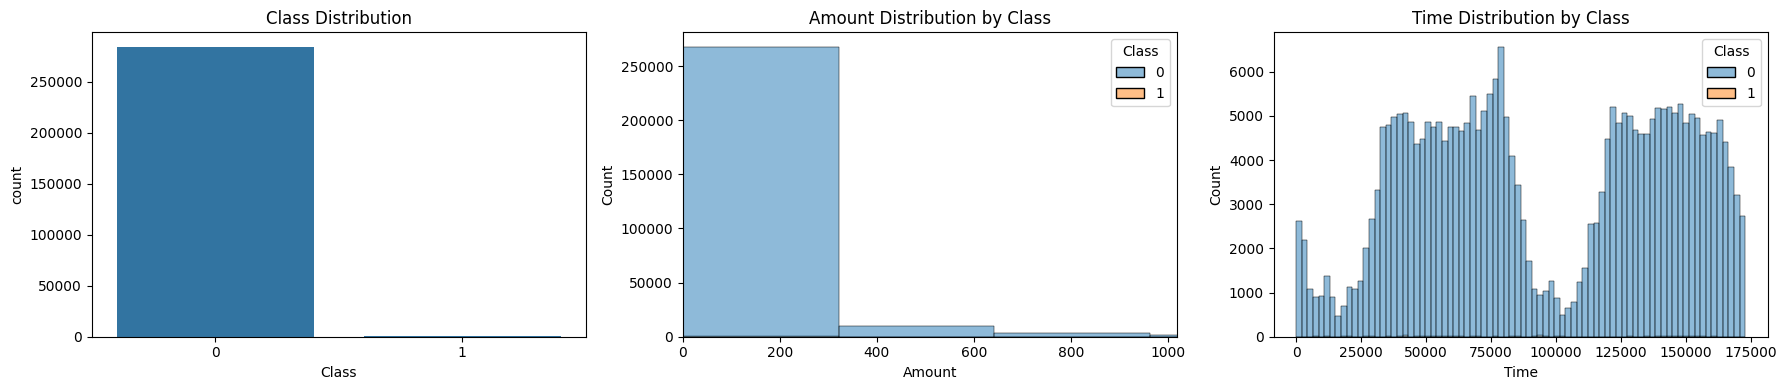

Class    1.000000
V17      0.326481
V14      0.302544
V12      0.260593
V10      0.216883
V16      0.196539
V3       0.192961
V7       0.187257
V11      0.154876
V4       0.133447
Name: Class, dtype: float64

In [3]:
print(f"Dataset shape: {data.shape}")
display(data.describe().T)

missing_values = data.isna().sum().sort_values(ascending=False)
print("Top missing values:")
display(missing_values.head())
print(f"Duplicate rows: {data.duplicated().sum()}")

class_distribution = data["Class"].value_counts().rename(index={0: "normal", 1: "fraud"})
class_ratio = data["Class"].value_counts(normalize=True).rename(index={0: "normal", 1: "fraud"})
display(pd.DataFrame({"count": class_distribution, "ratio": class_ratio}))

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.countplot(data=data, x="Class", ax=axes[0])
axes[0].set_title("Class Distribution")

sns.histplot(data=data, x="Amount", hue="Class", bins=80, ax=axes[1])
axes[1].set_title("Amount Distribution by Class")
axes[1].set_xlim(0, data["Amount"].quantile(0.99))

sns.histplot(data=data, x="Time", hue="Class", bins=80, ax=axes[2])
axes[2].set_title("Time Distribution by Class")
plt.tight_layout()
plt.show()

correlation_to_target = data.corr(numeric_only=True)["Class"].abs().sort_values(ascending=False)
display(correlation_to_target.head(10))

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

Untuk dataset ini, fitur `V1` sampai `V28` sudah berupa hasil PCA, sehingga preprocessing utama adalah validasi skema, stratified split, dan scaling untuk `Time` serta `Amount`.

In [ ]:
TARGET_COLUMN = "Class"
SCALE_COLUMNS = ["Time", "Amount"]
PCA_COLUMNS = [f"V{index}" for index in range(1, 29)]
FEATURE_COLUMNS = ["Time", *PCA_COLUMNS, "Amount"]
REQUIRED_COLUMNS = [*FEATURE_COLUMNS, TARGET_COLUMN]

missing_columns = sorted(set(REQUIRED_COLUMNS) - set(data.columns))
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

model_data = data[REQUIRED_COLUMNS].copy()=
train_df, test_df = train_test_split(
    model_data,
    test_size=0.2,
    random_state=42,
    stratify=model_data[TARGET_COLUMN],
)

scaler = StandardScaler()
train_df[SCALE_COLUMNS] = scaler.fit_transform(train_df[SCALE_COLUMNS])
test_df[SCALE_COLUMNS] = scaler.transform(test_df[SCALE_COLUMNS])

processed_dir = PROJECT_ROOT / "Membangun_model" / "cc_preprocessing" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)
train_df.to_csv(processed_dir / "train.csv", index=False)
test_df.to_csv(processed_dir / "test.csv", index=False)
joblib.dump(scaler, processed_dir / "amount_time_scaler.joblib")

metadata = {
    "feature_columns": FEATURE_COLUMNS,
    "target_column": TARGET_COLUMN,
    "scale_columns": SCALE_COLUMNS,
    "train_rows": int(len(train_df)),
    "test_rows": int(len(test_df)),
    "fraud_rate_train": float(train_df[TARGET_COLUMN].mean()),
    "fraud_rate_test": float(test_df[TARGET_COLUMN].mean()),
}
(processed_dir / "metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")

display(metadata)

{'feature_columns': ['Time',
  'V1',
  'V2',
  'V3',
  'V4',
  'V5',
  'V6',
  'V7',
  'V8',
  'V9',
  'V10',
  'V11',
  'V12',
  'V13',
  'V14',
  'V15',
  'V16',
  'V17',
  'V18',
  'V19',
  'V20',
  'V21',
  'V22',
  'V23',
  'V24',
  'V25',
  'V26',
  'V27',
  'V28',
  'Amount'],
 'target_column': 'Class',
 'scale_columns': ['Time', 'Amount'],
 'train_rows': 227845,
 'test_rows': 56962,
 'fraud_rate_train': 0.001729245759178389,
 'fraud_rate_test': 0.0017204452090867595}

# **6. Baseline Modeling dengan MLflow**

Baseline menggunakan Logistic Regression dengan `class_weight='balanced'`. Ini bukan model paling kuat, tapi penting sebagai pembanding sebelum tuning.

2026/06/12 13:38:55 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/12 13:38:55 INFO mlflow.store.db.utils: Updating database tables
2026/06/12 13:39:02 INFO mlflow.tracking.fluent: Experiment with name 'credit-card-fraud-detection' does not exist. Creating a new experiment.
e:\projects\Dicoding\.venv311\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
2026/06/12 13:39:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/12 13:39:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. Fo

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



{'average_precision': 0.7159122424484009,
 'roc_auc': 0.9721687370080279,
 'recall': 0.9183673469387755,
 'precision': 0.06097560975609756,
 'f1_score': 0.11435832274459974}

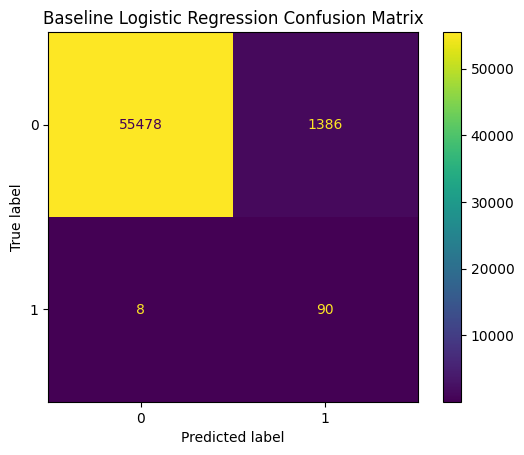

In [5]:
x_train = train_df.drop(columns=[TARGET_COLUMN])
y_train = train_df[TARGET_COLUMN].astype(int)
x_test = test_df.drop(columns=[TARGET_COLUMN])
y_test = test_df[TARGET_COLUMN].astype(int)

baseline_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    n_jobs=-1,
    random_state=42,
)

mlflow.set_experiment("credit-card-fraud-detection")
with mlflow.start_run(run_name="notebook_baseline_logistic_regression"):
    baseline_model.fit(x_train, y_train)
    y_proba = baseline_model.predict_proba(x_test)[:, 1]
    y_pred = baseline_model.predict(x_test)

    baseline_metrics = {
        "average_precision": average_precision_score(y_test, y_proba),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "f1_score": f1_score(y_test, y_pred, zero_division=0),
    }
    mlflow.log_params({"model_type": "LogisticRegression", "class_weight": "balanced"})
    mlflow.log_metrics(baseline_metrics)
    mlflow.sklearn.log_model(baseline_model, artifact_path="model")

print(classification_report(y_test, y_pred, zero_division=0))
display(baseline_metrics)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Baseline Logistic Regression Confusion Matrix")
plt.show()

# **7. Hyperparameter Tuning dan Model Final**

Model final menggunakan Random Forest dengan pencarian hyperparameter. Metric utama adalah `average_precision` atau PR-AUC karena dataset sangat imbalanced. Accuracy doang kurang aman buat kasus fraud.

Fitting 3 folds for each of 8 candidates, totalling 24 fits


2026/06/12 13:59:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/12 13:59:29 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.71      0.77        98

    accuracy                           1.00     56962
   macro avg       0.92      0.86      0.88     56962
weighted avg       1.00      1.00      1.00     56962



{'n_estimators': 100,
 'min_samples_split': 5,
 'min_samples_leaf': 1,
 'max_features': 'log2',
 'max_depth': 16}

{'average_precision': 0.8360370966189258,
 'roc_auc': 0.9576459012839801,
 'recall': 0.7142857142857143,
 'precision': 0.8333333333333334,
 'f1_score': 0.7692307692307693,
 'best_cv_average_precision': 0.8710989327350317}

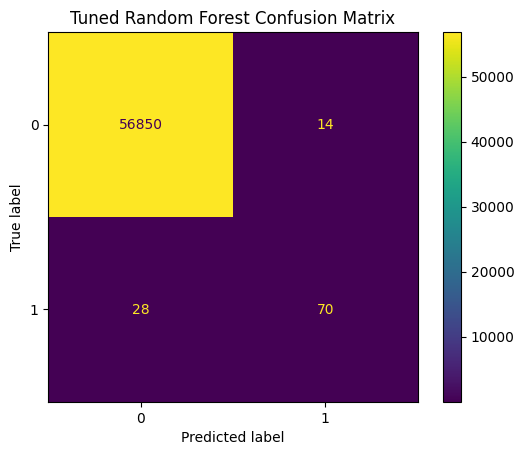

In [6]:
max_train_rows = min(80000, len(train_df))
tuning_train_df, _ = train_test_split(
    train_df,
    train_size=max_train_rows,
    random_state=42,
    stratify=train_df[TARGET_COLUMN],
)

x_tuning = tuning_train_df.drop(columns=[TARGET_COLUMN])
y_tuning = tuning_train_df[TARGET_COLUMN].astype(int)

random_forest = RandomForestClassifier(
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=42,
)
param_distributions = {
    "n_estimators": [100, 200, 300],
    "max_depth": [8, 12, 16, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
}
search = RandomizedSearchCV(
    estimator=random_forest,
    param_distributions=param_distributions,
    n_iter=8,
    scoring="average_precision",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

artifacts_dir = PROJECT_ROOT / "Membangun_model" / "artifacts"
artifacts_dir.mkdir(parents=True, exist_ok=True)

with mlflow.start_run(run_name="notebook_tuned_random_forest"):
    search.fit(x_tuning, y_tuning)
    tuned_model = search.best_estimator_
    tuned_proba = tuned_model.predict_proba(x_test)[:, 1]
    tuned_pred = tuned_model.predict(x_test)

    tuned_metrics = {
        "average_precision": average_precision_score(y_test, tuned_proba),
        "roc_auc": roc_auc_score(y_test, tuned_proba),
        "recall": recall_score(y_test, tuned_pred, zero_division=0),
        "precision": precision_score(y_test, tuned_pred, zero_division=0),
        "f1_score": f1_score(y_test, tuned_pred, zero_division=0),
        "best_cv_average_precision": float(search.best_score_),
    }
    mlflow.log_params({"model_type": "RandomForestClassifier", **search.best_params_})
    mlflow.log_metrics(tuned_metrics)
    mlflow.sklearn.log_model(tuned_model, artifact_path="model")

    joblib.dump(tuned_model, artifacts_dir / "model.joblib")
    joblib.dump(scaler, artifacts_dir / "amount_time_scaler.joblib")
    (artifacts_dir / "feature_columns.json").write_text(
        json.dumps(FEATURE_COLUMNS, indent=2), encoding="utf-8"
    )
    mlflow.log_artifacts(str(artifacts_dir))

print(classification_report(y_test, tuned_pred, zero_division=0))
display(search.best_params_)
display(tuned_metrics)
ConfusionMatrixDisplay.from_predictions(y_test, tuned_pred)
plt.title("Tuned Random Forest Confusion Matrix")
plt.show()

# **8. Kesimpulan Eksperimen**

- Dataset fraud sangat imbalanced, jadi metric utama adalah PR-AUC dan recall.
- Logistic Regression dipakai sebagai baseline.
- Random Forest hasil tuning dipakai sebagai model final untuk serving.
- Artifact final disimpan ke `Membangun_model/artifacts/` agar bisa dipakai oleh FastAPI dan monitoring stack.